In [1]:
import pandas as pd

df = pd.read_parquet("../data/performance_period_analysis.parquet")

for freq in ["mensal", "trimestral", "anual"]:
    print(f"\n=== {freq.upper()} ===")
    view = (
        df[df["frequencia"] == freq]
        .sort_values("retorno_periodo", ascending=False)
        [["periodo", "Estratégia", "Volume Mínimo", "Ativos na Carteira", "retorno_periodo", "dias_observados", "ativos_sem_valor"]]
    )
    print(view.to_string(index=False))



=== MENSAL ===
   periodo     Estratégia  Volume Mínimo  Ativos na Carteira  retorno_periodo  dias_observados  ativos_sem_valor
2026-03-31           ROIC         400000                   5         3.957476                7                 1
2026-03-31           ROIC        1000000                   5         3.957476                7                 1
2026-03-31           ROIC        1000000                  10         3.669729                7                 2
2026-03-31 Earnings Yield         400000                   5         3.174931                7                 2
2026-03-31 Earnings Yield        1000000                   5         3.174931                7                 2
2026-03-31           ROIC         400000                  10         3.164609                7                 3
2026-03-31 Earnings Yield        1000000                  10         2.959367                7                 3
2026-03-31 Earnings Yield         400000                  10         2.959367   

In [2]:
import pandas as pd

df = pd.read_parquet("../data/performance_period_analysis.parquet")

carteira_vencedora = (
    df.sort_values("retorno_periodo", ascending=False)
      .iloc[0]
)

carteira_vencedora


periodo                     2026-03-31 00:00:00
data_inicial                2026-03-10 00:00:00
data_final                  2026-03-18 00:00:00
valor_inicial                          99991.23
valor_final                           495704.09
dias_observados                               7
ativos                                        5
ativos_sem_valor                              1
ultimo_commit         2026-03-18 12:00:11+00:00
Estratégia                                 ROIC
Volume Mínimo                            400000
Ativos na Carteira                            5
frequencia                               mensal
retorno_periodo                        3.957476
Name: 40, dtype: object

In [3]:
df = pd.read_parquet("../data/performance_period_analysis.parquet")

(
    df.sort_values("retorno_periodo", ascending=False)
      [["frequencia", "periodo", "Estratégia", "Volume Mínimo", "Ativos na Carteira", "retorno_periodo", "valor_inicial", "valor_final"]]
      .head(1)
)


,frequencia,periodo,Estratégia,Volume Mínimo,Ativos na Carteira,retorno_periodo,valor_inicial,valor_final
40,mensal,2026-03-31,ROIC,400000,5,3.957476,99991.23,495704.09


In [ ]:
import pandas as pd

analysis = pd.read_parquet("../data/performance_period_analysis.parquet")
history = pd.read_parquet("../data/performance_committed_since_2026-03-10.parquet")

winner = analysis.sort_values("retorno_periodo", ascending=False).iloc[0]

history["Data"] = pd.to_datetime(history["Data"])
history["commit_committed_at"] = pd.to_datetime(history["commit_committed_at"], utc=True)

latest = (
    history.sort_values("commit_committed_at")
    .drop_duplicates(
        subset=["Estratégia", "Volume Mínimo", "Ativos na Carteira", "Data", "papel"],
        keep="last",
    )
)

carteira_final = (
    latest[
        (latest["Estratégia"] == winner["Estratégia"]) &
        (latest["Volume Mínimo"] == winner["Volume Mínimo"]) &
        (latest["Ativos na Carteira"] == winner["Ativos na Carteira"]) &
        (latest["Data"] == winner["data_final"])
    ][["papel", "Cotação", "Quantidade", "Valor"]]
    .sort_values("Valor", ascending=False)
    .reset_index(drop=True)
)

comparativo = pd.DataFrame(
    [{
        "frequencia": winner["frequencia"],
        "periodo": winner["periodo"],
        "estrategia": winner["Estratégia"],
        "volume_minimo": winner["Volume Mínimo"],
        "ativos_na_carteira": winner["Ativos na Carteira"],
        "data_inicial": winner["data_inicial"],
        "data_final": winner["data_final"],
        "valor_inicial": winner["valor_inicial"],
        "valor_final": winner["valor_final"],
        "retorno_periodo": winner["retorno_periodo"],
    }]
)

display(comparativo)
display(carteira_final)


,papel,Cotação,Quantidade,Valor,valor_inicial_carteira,valor_final_carteira,retorno_periodo,data_inicial,data_final
0,CURY3,36.30,3971.0,144147.30,99991.23,495704.09,3.957476,2026-03-10,2026-03-18
1,PLPL3,14.48,8691.0,125845.68,99991.23,495704.09,3.957476,2026-03-10,2026-03-18
2,PSSA3,48.00,2382.0,114336.00,99991.23,495704.09,3.957476,2026-03-10,2026-03-18
3,ODPV3,13.27,8393.0,111375.11,99991.23,495704.09,3.957476,2026-03-10,2026-03-18
4,LEVE3,34.49,NaN,NaN,99991.23,495704.09,3.957476,2026-03-10,2026-03-18


In [9]:
import pandas as pd
import numpy as np

analysis = pd.read_parquet("../data/performance_period_analysis.parquet")
history = pd.read_parquet("../data/performance_committed_since_2026-03-10.parquet")

winner = analysis.sort_values("retorno_periodo", ascending=False).iloc[0]

history["Data"] = pd.to_datetime(history["Data"])
history["commit_committed_at"] = pd.to_datetime(history["commit_committed_at"], utc=True)

latest = (
    history.sort_values("commit_committed_at")
    .drop_duplicates(
        subset=["Estratégia", "Volume Mínimo", "Ativos na Carteira", "Data", "papel"],
        keep="last",
    )
)

filtro_base = (
    (latest["Estratégia"] == winner["Estratégia"]) &
    (latest["Volume Mínimo"] == winner["Volume Mínimo"]) &
    (latest["Ativos na Carteira"] == winner["Ativos na Carteira"])
)

inicial = (
    latest[
        filtro_base &
        (latest["Data"] == winner["data_inicial"])
    ][["papel", "Cotação", "Quantidade", "Valor"]]
    .rename(columns={
        "Cotação": "cotacao_inicial",
        "Quantidade": "quantidade_inicial",
        "Valor": "valor_inicial_ativo",
    })
)

final = (
    latest[
        filtro_base &
        (latest["Data"] == winner["data_final"])
    ][["papel", "Cotação", "Quantidade", "Valor"]]
    .rename(columns={
        "Cotação": "cotacao_final",
        "Quantidade": "quantidade_final",
        "Valor": "valor_final_ativo",
    })
)

comparativo = (
    inicial.merge(final, on="papel", how="outer")
    .assign(
        valor_inicial_ativo=lambda df: df["valor_inicial_ativo"].fillna(0),
        valor_final_ativo=lambda df: df["valor_final_ativo"].fillna(0),
    )
)

total_inicial = winner["valor_inicial"]
total_final = winner["valor_final"]

comparativo["peso_inicial"] = comparativo["valor_inicial_ativo"] / total_inicial
comparativo["peso_final"] = comparativo["valor_final_ativo"] / total_final

comparativo["variacao_cotacao"] = np.where(
    comparativo["cotacao_inicial"].notna() & comparativo["cotacao_final"].notna(),
    comparativo["cotacao_final"] / comparativo["cotacao_inicial"] - 1,
    np.nan,
)

comparativo["variacao_valor_ativo"] = np.where(
    comparativo["valor_inicial_ativo"].ne(0),
    comparativo["valor_final_ativo"] / comparativo["valor_inicial_ativo"] - 1,
    np.nan,
)

comparativo["variacao_peso"] = comparativo["peso_final"] - comparativo["peso_inicial"]

comparativo["status"] = np.select(
    [
        comparativo["cotacao_inicial"].isna(),
        comparativo["cotacao_final"].isna(),
    ],
    [
        "entrou",
        "saiu",
    ],
    default="permaneceu",
)

comparativo = comparativo.sort_values(
    ["status", "valor_final_ativo", "valor_inicial_ativo"],
    ascending=[True, False, False]
).reset_index(drop=True)

resumo = pd.DataFrame(
    [{
        "frequencia": winner["frequencia"],
        "periodo": winner["periodo"],
        "estrategia": winner["Estratégia"],
        "volume_minimo": winner["Volume Mínimo"],
        "ativos_na_carteira": winner["Ativos na Carteira"],
        "data_inicial": winner["data_inicial"],
        "data_final": winner["data_final"],
        "valor_inicial_carteira": winner["valor_inicial"],
        "valor_final_carteira": winner["valor_final"],
        "retorno_periodo": winner["retorno_periodo"],
    }]
)

display(resumo)
display(comparativo)


,frequencia,periodo,estrategia,volume_minimo,ativos_na_carteira,data_inicial,data_final,valor_inicial_carteira,valor_final_carteira,retorno_periodo
0,mensal,2026-03-31,ROIC,400000,5,2026-03-10,2026-03-18,99991.23,495704.09,3.957476


,papel,cotacao_inicial,quantidade_inicial,valor_inicial_ativo,cotacao_final,quantidade_final,valor_final_ativo,peso_inicial,peso_final,variacao_cotacao,variacao_valor_ativo,variacao_peso,status
0,CURY3,17.30,1156.0,19998.80,36.30,3971.0,144147.30,0.200006,0.290793,1.098266,6.207797,0.090788,permaneceu
1,PLPL3,9.00,2222.0,19998.00,14.48,8691.0,125845.68,0.199998,0.253873,0.608889,5.292913,0.053875,permaneceu
2,PSSA3,34.77,575.0,19992.75,48.00,2382.0,114336.00,0.199945,0.230654,0.380500,4.718873,0.030709,permaneceu
3,ODPV3,10.32,1938.0,20000.16,13.27,8393.0,111375.11,0.200019,0.224681,0.285853,4.568711,0.024661,permaneceu
4,LEVE3,26.18,764.0,20001.52,34.49,NaN,0.00,0.200033,0.000000,0.317418,-1.000000,-0.200033,permaneceu


In [17]:
comparativo_formatado = comparativo.copy()

for col in ["peso_inicial", "peso_final", "variacao_cotacao", "variacao_valor_ativo", "variacao_peso"]:
    comparativo_formatado[col] = comparativo_formatado[col].map(
        lambda x: f"{x:.2%}" if pd.notna(x) else "-"
    )

comparativo_formatado


,papel,cotacao_inicial,quantidade_inicial,valor_inicial_ativo,cotacao_final,quantidade_final,valor_final_ativo,peso_inicial,peso_final,variacao_cotacao,variacao_valor_ativo,variacao_peso,status
0,CURY3,17.30,1156.0,19998.80,36.30,3971.0,144147.30,20.00%,29.08%,109.83%,620.78%,9.08%,permaneceu
1,PLPL3,9.00,2222.0,19998.00,14.48,8691.0,125845.68,20.00%,25.39%,60.89%,529.29%,5.39%,permaneceu
2,PSSA3,34.77,575.0,19992.75,48.00,2382.0,114336.00,19.99%,23.07%,38.05%,471.89%,3.07%,permaneceu
3,ODPV3,10.32,1938.0,20000.16,13.27,8393.0,111375.11,20.00%,22.47%,28.59%,456.87%,2.47%,permaneceu
4,LEVE3,26.18,764.0,20001.52,34.49,NaN,0.00,20.00%,0.00%,31.74%,-100.00%,-20.00%,permaneceu


In [18]:
import pandas as pd

hist = pd.read_parquet("../data/performance_committed_since_2026-03-10.parquet")
hist["Data"] = pd.to_datetime(hist["Data"])
hist["commit_committed_at"] = pd.to_datetime(hist["commit_committed_at"], utc=True)

latest_hist = (
    hist.sort_values("commit_committed_at")
    .drop_duplicates(
        subset=["Estratégia", "Volume Mínimo", "Ativos na Carteira", "Data", "papel"],
        keep="last",
    )
)

carteira_cury = latest_hist[
    (latest_hist["papel"] == "CURY3") &
    (latest_hist["Estratégia"] == "ROIC") &
    (latest_hist["Volume Mínimo"] == 400000) &
    (latest_hist["Ativos na Carteira"] == 5)
][["Data", "Cotação", "Quantidade", "Valor"]]

fund = pd.read_parquet("../data/fundamentus_data.parquet")
fund_cury = fund.loc[fund.index == "CURY3", ["Cotação", "update date"]].reset_index()

display(carteira_cury)
display(fund_cury)


,Data,Cotação,Quantidade,Valor
263,2026-03-10,17.30,1156.0,19998.8
653,2026-03-11,17.30,2312.0,39997.6
1042,2026-03-12,37.30,2312.0,86237.6
1432,2026-03-13,36.20,2864.0,103676.8
1822,2026-03-16,35.94,3420.0,122914.8
2212,2026-03-17,36.49,3420.0,124795.8
2602,2026-03-18,36.30,3971.0,144147.3


,index,Cotação,update date
0,CURY3,35.59,2026-03-10
1,CURY3,35.59,2026-03-11
2,CURY3,37.30,2026-03-12
3,CURY3,36.20,2026-03-13
4,CURY3,35.94,2026-03-16
5,CURY3,36.49,2026-03-17
6,CURY3,36.30,2026-03-18


In [1]:
import pandas as pd

performance = pd.read_csv('../data/performance.csv')
performance

,papel,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,...,Earnings Yield,Valor,Quantidade,Estratégia,Ativos na Carteira,Volume Mínimo,Data,Ranking_EY,Ranking_ROIC,Magic Formula
0,IRBR3,54.93,0.00,0.85,0.863,0.0000,0.287,0.00,8.03,0.00,...,inf,72287.88,1316.0,Earnings Yield,5,400000,2026-03-13,NaN,NaN,NaN
1,PSSA3,48.94,9.36,2.01,0.774,0.0406,0.566,4.70,0.94,-4.74,...,175.4,76297.46,1559.0,Earnings Yield,5,400000,2026-03-13,NaN,NaN,NaN
2,PCAR3,2.48,-1.48,0.58,0.064,0.0000,0.066,-0.99,0.77,-0.12,...,47.8,NaN,NaN,Earnings Yield,5,400000,2026-03-13,NaN,NaN,NaN
3,WIZC3,9.09,7.65,2.08,1.064,0.0623,0.602,38.35,2.10,-2.65,...,44.8,90318.24,9936.0,Earnings Yield,5,400000,2026-03-13,NaN,NaN,NaN
4,QUAL3,1.83,48.73,0.40,0.364,0.0030,0.132,-4.13,0.88,-0.37,...,42.2,NaN,NaN,Earnings Yield,5,400000,2026-03-13,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,MULT3,30.97,13.93,2.52,5.802,0.0330,1.208,39.38,8.11,-3.27,...,9.5,NaN,NaN,ROIC,30,1000000,2026-03-13,NaN,NaN,NaN
386,CPFE3,48.24,10.14,2.47,1.253,0.0579,0.685,-44.13,4.87,-1.36,...,14.0,NaN,NaN,ROIC,30,1000000,2026-03-13,NaN,NaN,NaN
387,RANI3,9.27,8.83,1.47,1.267,0.0649,0.541,2.39,4.69,-1.94,...,14.2,NaN,NaN,ROIC,30,1000000,2026-03-13,NaN,NaN,NaN
388,RDOR3,37.26,18.19,4.41,1.531,0.1152,0.801,2.47,8.68,-2.74,...,10.8,NaN,NaN,ROIC,30,1000000,2026-03-13,NaN,NaN,NaN


In [3]:
strategy = 'Earnings Yield'
ranking_var = 'Ranking_EY'

performance.loc[
    (performance.Data == max(performance.Data))
    &(performance['Ativos na Carteira'] == 20)
    &(performance['Volume Mínimo']== 1000000)
    &(performance['Estratégia']==strategy)
    ].drop_duplicates(subset=['papel',ranking_var]).head(20).reset_index(drop=True)['papel'].unique()

array(['IRBR3', 'PSSA3', 'PCAR3', 'WIZC3', 'QUAL3', 'GOAU4', 'PLPL3',
       'ALLD3', 'ASAI3', 'CEAB3', 'LREN3', 'CASH3', 'CMIN3', 'PFRM3',
       'VTRU3', 'RIAA3', 'BEEF3', 'PETR4', 'SEER3', 'BHIA3'], dtype=object)

In [2]:
performance.loc[
    (performance['Estratégia'] == 'Earnings Yield')
    &(performance['Volume Mínimo']>400000)
    ]

,papel,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,...,Earnings Yield,Valor,Quantidade,Estratégia,Ativos na Carteira,Volume Mínimo,Data,Ranking_EY,Ranking_ROIC,Magic Formula
5,IRBR3,54.93,0.00,0.85,0.863,0.0000,0.287,0.00,8.03,0.00,...,inf,72287.88,1316.0,Earnings Yield,5,1000000,2026-03-13,NaN,NaN,NaN
6,PSSA3,48.94,9.36,2.01,0.774,0.0406,0.566,4.70,0.94,-4.74,...,175.4,76297.46,1559.0,Earnings Yield,5,1000000,2026-03-13,NaN,NaN,NaN
7,PCAR3,2.48,-1.48,0.58,0.064,0.0000,0.066,-0.99,0.77,-0.12,...,47.8,NaN,NaN,Earnings Yield,5,1000000,2026-03-13,NaN,NaN,NaN
8,WIZC3,9.09,7.65,2.08,1.064,0.0623,0.602,38.35,2.10,-2.65,...,44.8,90318.24,9936.0,Earnings Yield,5,1000000,2026-03-13,NaN,NaN,NaN
9,QUAL3,1.83,48.73,0.40,0.364,0.0030,0.132,-4.13,0.88,-0.37,...,42.2,NaN,NaN,Earnings Yield,5,1000000,2026-03-13,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,COGN3,2.96,9.77,0.45,0.871,0.0557,0.253,3.26,2.98,-1.02,...,17.8,NaN,NaN,Earnings Yield,30,1000000,2026-03-13,NaN,NaN,NaN
126,GMAT3,5.02,6.11,1.13,0.316,0.0485,0.488,1.94,5.04,-204.15,...,17.7,NaN,NaN,Earnings Yield,30,1000000,2026-03-13,NaN,NaN,NaN
127,DEXP3,7.30,5.75,0.86,0.407,0.1147,0.558,1.21,6.30,1.90,...,17.5,NaN,NaN,Earnings Yield,30,1000000,2026-03-13,NaN,NaN,NaN
128,MYPK3,9.35,14.61,0.33,0.094,0.0328,0.100,0.53,1.52,-0.43,...,17.3,NaN,NaN,Earnings Yield,30,1000000,2026-03-13,NaN,NaN,NaN


In [15]:
df = fd.get_papel('CSNA3')
df

2026-03-10 10:53:31,326 [detalhes.get_papel] INFO: detalhes: call: get..._papel()
/home/gus/.cache/pypoetry/virtualenvs/magic-app-X1JMDIUZ-py3.12/lib/python3.12/site-packages/fundamentus/detalhes.py:232: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  time.sleep(.500) # 500 ms


,Papel,Tipo,Empresa,Setor,Subsetor,Cotacao,Data_ult_cot,Min_52_sem,Max_52_sem,Vol_med_2m,...,Ativo_Circulante,Div_Bruta,Div_Liquida,Patrim_Liq,Receita_Liquida_12m,EBIT_12m,Lucro_Liquido_12m,Receita_Liquida_3m,EBIT_3m,Lucro_Liquido_3m
CSNA3,CSNA3,ON,CSN ON,Siderurgia e Metalurgia,Siderurgia,7.19,2026-03-09,6.77,10.89,128973000,...,32836600000,52147000000,34706800000,14141900000,45420900000,6566930000,-1555260000,11793900000,1907530000,-137080000


In [11]:
data.columns

Index(['Cotação', 'P/L', 'P/VP', 'PSR', 'Div.Yield', 'P/Ativo', 'P/Cap.Giro',
       'P/EBIT', 'P/Ativ Circ.Liq', 'EV/EBIT', 'EV/EBITDA', 'Mrg Ebit',
       'Mrg. Líq.', 'Liq. Corr.', 'ROIC', 'ROE', 'Liq.2meses', 'Patrim. Líq',
       'Dív.Brut/ Patrim.', 'Cresc. Rec.5a'],
      dtype='object', name='Multiples')

In [10]:
df.columns

Index(['Papel', 'Tipo', 'Empresa', 'Setor', 'Subsetor', 'Cotacao',
       'Data_ult_cot', 'Min_52_sem', 'Max_52_sem', 'Vol_med_2m',
       'Valor_de_mercado', 'Valor_da_firma', 'Ult_balanco_processado',
       'Nro_Acoes', 'PL', 'PVP', 'PEBIT', 'PSR', 'PAtivos', 'PCap_Giro',
       'PAtiv_Circ_Liq', 'Div_Yield', 'EV_EBITDA', 'EV_EBIT', 'Cres_Rec_5a',
       'LPA', 'VPA', 'Marg_Bruta', 'Marg_EBIT', 'Marg_Liquida', 'EBIT_Ativo',
       'ROIC', 'ROE', 'Liquidez_Corr', 'Div_Br_Patrim', 'Giro_Ativos', 'Ativo',
       'Disponibilidades', 'Ativo_Circulante', 'Div_Bruta', 'Div_Liquida',
       'Patrim_Liq', 'Receita_Liquida_12m', 'EBIT_12m', 'Lucro_Liquido_12m',
       'Receita_Liquida_3m', 'EBIT_3m', 'Lucro_Liquido_3m'],
      dtype='object')

In [11]:
import pandas as pd
import fundamentus as fd

# Get the data
data = fd.get_resultado_raw()

# # add the update date

# data['update date'] = pd.to_datetime('today').strftime('%Y-%m-%d')

# # read the previous data
# previous_data = pd.read_parquet('../data/fundamentus_data.parquet')

# # append the new data
# data = pd.concat([previous_data, data])

# data['ticker'] = data.index

# # drop duplicates
# data.drop_duplicates(subset = ['ticker','update date'], keep = 'last', inplace = True)

# # drop ticker column
# data.drop(columns = 'ticker', inplace = True)

# # Save the data in parquet
# #data.to_parquet('../data/fundamentus_data.parquet', engine = 'pyarrow')
data.loc[data.index == 'CURY3']

2026-03-18 12:25:02,125 [logging.log_init] INFO: LOGLEVEL=INFO


Multiples,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,EV/EBIT,EV/EBITDA,Mrg Ebit,Mrg. Líq.,Liq. Corr.,ROIC,ROE,Liq.2meses,Patrim. Líq,Dív.Brut/ Patrim.,Cresc. Rec.5a
papel,,,,,,,,,,,,,,,,,,,,
CURY3,36.3,11.46,8.09,2.071,0.1083,1.978,7.62,7.92,-14.33,7.69,7.51,0.2616,0.2002,1.84,0.394,0.706,117522000.0,1.381710e+09,1.07,0.3258


In [8]:
df.index

Index(['ATED3', 'FICT3', 'REAG3', 'AALR3', 'ABCB3', 'ABCB4', 'ABEV3', 'ABYA3',
       'ACES3', 'ACES4',
       ...
       'WHRL4', 'WISA3', 'WISA4', 'WIZC3', 'WLMM3', 'WLMM4', 'WMBY3', 'WSON33',
       'YDUQ3', 'ZAMP3'],
      dtype='object', name='papel', length=362851)

In [16]:
import pandas as pd
df = pd.read_parquet('../data/fundamentus_data.parquet', engine = 'pyarrow')

df.loc[df.index == 'CURY3']

,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,EV/EBIT,...,Mrg Ebit,Mrg. Líq.,Liq. Corr.,ROIC,ROE,Liq.2meses,Patrim. Líq,Dív.Brut/ Patrim.,Cresc. Rec.5a,update date
CURY3,35.59,12.583631,7.914555,2.186261,NaN,1.946626,645.00,8.600094,-1880.00,8.246941,...,0.254214,0.173739,200.00,NaN,0.628956,115402000.0,1.385220e+09,0.955076,NaN,2026-03-10
CURY3,35.59,12.583631,7.914555,2.186261,NaN,1.946626,645.00,8.600094,-1880.00,8.246941,...,0.254214,0.173739,200.00,NaN,0.628956,115402000.0,1.385220e+09,0.955076,NaN,2026-03-11
CURY3,37.30,11.780000,8.320000,2.128000,0.1054,2.032000,7.83,8.140000,-14.72,7.910000,...,0.261600,0.200200,1.84,0.394,0.706000,117357000.0,1.381710e+09,1.070000,0.3258,2026-03-12
CURY3,36.20,11.430000,8.070000,2.065000,0.1086,1.972000,7.60,7.900000,-14.29,7.670000,...,0.261600,0.200200,1.84,0.394,0.706000,117937000.0,1.381710e+09,1.070000,0.3258,2026-03-13
CURY3,35.94,11.350000,8.010000,2.050000,0.1093,1.958000,7.54,7.840000,-14.19,7.620000,...,0.261600,0.200200,1.84,0.394,0.706000,119489000.0,1.381710e+09,1.070000,0.3258,2026-03-16
CURY3,36.49,11.520000,8.140000,2.082000,0.1077,1.988000,7.66,7.960000,-14.40,7.740000,...,0.261600,0.200200,1.84,0.394,0.706000,117883000.0,1.381710e+09,1.070000,0.3258,2026-03-17
CURY3,36.30,11.460000,8.090000,2.071000,0.1083,1.978000,7.62,7.920000,-14.33,7.690000,...,0.261600,0.200200,1.84,0.394,0.706000,117522000.0,1.381710e+09,1.070000,0.3258,2026-03-18


In [15]:
plot_df

,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,EV/EBIT,...,Mrg Ebit,Mrg. Líq.,Liq. Corr.,ROIC,ROE,Liq.2meses,Patrim. Líq,Dív.Brut/ Patrim.,Cresc. Rec.5a,update date
CURY3,35.59,12.583631,7.914555,2.186261,NaN,1.946626,645.00,8.600094,-1880.00,8.246941,...,0.254214,0.173739,200.00,NaN,0.628956,115402000.0,1.385220e+09,0.955076,NaN,2026-03-10
CURY3,35.59,12.583631,7.914555,2.186261,NaN,1.946626,645.00,8.600094,-1880.00,8.246941,...,0.254214,0.173739,200.00,NaN,0.628956,115402000.0,1.385220e+09,0.955076,NaN,2026-03-11
CURY3,37.30,11.780000,8.320000,2.128000,0.1054,2.032000,7.83,8.140000,-14.72,7.910000,...,0.261600,0.200200,1.84,0.394,0.706000,117357000.0,1.381710e+09,1.070000,0.3258,2026-03-12
CURY3,36.20,11.430000,8.070000,2.065000,0.1086,1.972000,7.60,7.900000,-14.29,7.670000,...,0.261600,0.200200,1.84,0.394,0.706000,117937000.0,1.381710e+09,1.070000,0.3258,2026-03-13
CURY3,35.94,11.350000,8.010000,2.050000,0.1093,1.958000,7.54,7.840000,-14.19,7.620000,...,0.261600,0.200200,1.84,0.394,0.706000,119489000.0,1.381710e+09,1.070000,0.3258,2026-03-16
CURY3,36.49,11.520000,8.140000,2.082000,0.1077,1.988000,7.66,7.960000,-14.40,7.740000,...,0.261600,0.200200,1.84,0.394,0.706000,117883000.0,1.381710e+09,1.070000,0.3258,2026-03-17
CURY3,36.30,11.460000,8.090000,2.071000,0.1083,1.978000,7.62,7.920000,-14.33,7.690000,...,0.261600,0.200200,1.84,0.394,0.706000,117522000.0,1.381710e+09,1.070000,0.3258,2026-03-18


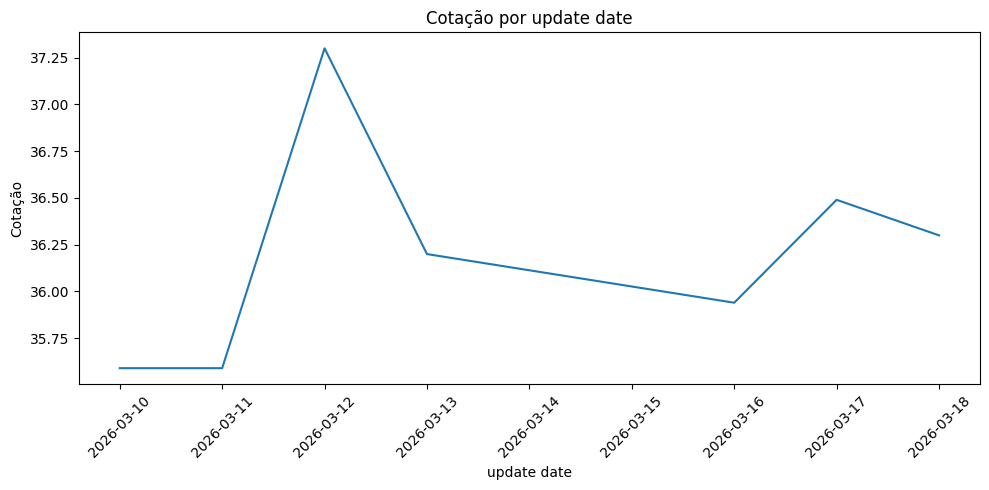

In [14]:
import matplotlib.pyplot as plt

plot_df = df.loc[df.index == 'CURY3'].copy()
plot_df['update date'] = pd.to_datetime(plot_df['update date'])
plot_df = plot_df.sort_values('update date')

plt.figure(figsize=(10, 5))
plt.plot(plot_df['update date'], plot_df['Cotação'])
plt.xlabel('update date')
plt.ylabel('Cotação')
plt.title('Cotação por update date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [1]:
import pandas as pd
import fundamentus as fd
import fundamentus.detalhes as fd_detalhes
import warnings
from pandas.io.html import read_html as pandas_read_html
from IPython.display import clear_output

warnings.filterwarnings('ignore')

def _read_html_lxml(*args, **kwargs):
    kwargs.setdefault('flavor', 'lxml')
    return pandas_read_html(*args, **kwargs)

fd_detalhes.pd.read_html = _read_html_lxml

raw_data = fd.get_resultado_raw()
detailed_frames = []
failed_tickers = []

total_tickers = len(raw_data.index)

for i, papel in enumerate(raw_data.index, start=1):
    clear_output(wait=True)
    print(f'Progresso: {i}/{total_tickers} | Papel: {papel}')
    try:
        detailed_frames.append(fd.get_papel(papel))
    except Exception as exc:
        failed_tickers.append((papel, str(exc)))

detailed_data = (
    pd.concat(detailed_frames, ignore_index=False)
    if detailed_frames
    else pd.DataFrame(index=raw_data.index)
)
if not detailed_data.empty:
    detailed_data = detailed_data[~detailed_data.index.duplicated(keep='last')]
    detailed_data = detailed_data.reindex(raw_data.index)

numeric_columns = [
    'Cotacao', 'Valor_de_mercado', 'Lucro_Liquido_12m', 'Patrim_Liq',
    'Receita_Liquida_12m', 'Div_Yield', 'Ativo', 'PCap_Giro', 'EBIT_12m',
    'PAtiv_Circ_Liq', 'Valor_da_firma', 'EV_EBITDA', 'Liquidez_Corr',
    'ROIC', 'Vol_med_2m', 'Div_Bruta', 'Cres_Rec_5a'
]
available_numeric_columns = [
    column for column in numeric_columns if column in detailed_data.columns
]
detailed_data[available_numeric_columns] = detailed_data[available_numeric_columns].apply(
    pd.to_numeric,
    errors='coerce',
)

def safe_div(numerator, denominator):
    denominator = denominator.replace(0, pd.NA)
    return numerator.divide(denominator)

transformed_data = pd.DataFrame(index=detailed_data.index)
transformed_data['Cotação'] = detailed_data['Cotacao']
transformed_data['P/L'] = safe_div(
    detailed_data['Valor_de_mercado'],
    detailed_data['Lucro_Liquido_12m'],
)
transformed_data['P/VP'] = safe_div(
    detailed_data['Valor_de_mercado'],
    detailed_data['Patrim_Liq'],
)
transformed_data['PSR'] = safe_div(
    detailed_data['Valor_de_mercado'],
    detailed_data['Receita_Liquida_12m'],
)
transformed_data['Div.Yield'] = detailed_data['Div_Yield']
transformed_data['P/Ativo'] = safe_div(
    detailed_data['Valor_de_mercado'],
    detailed_data['Ativo'],
)
transformed_data['P/Cap.Giro'] = detailed_data['PCap_Giro']
transformed_data['P/EBIT'] = safe_div(
    detailed_data['Valor_de_mercado'],
    detailed_data['EBIT_12m'],
)
transformed_data['P/Ativ Circ.Liq'] = detailed_data['PAtiv_Circ_Liq']
transformed_data['EV/EBIT'] = safe_div(
    detailed_data['Valor_da_firma'],
    detailed_data['EBIT_12m'],
)
transformed_data['EV/EBITDA'] = detailed_data['EV_EBITDA']
transformed_data['Mrg Ebit'] = safe_div(
    detailed_data['EBIT_12m'],
    detailed_data['Receita_Liquida_12m'],
)
transformed_data['Mrg. Líq.'] = safe_div(
    detailed_data['Lucro_Liquido_12m'],
    detailed_data['Receita_Liquida_12m'],
)
transformed_data['Liq. Corr.'] = detailed_data['Liquidez_Corr']
transformed_data['ROIC'] = detailed_data['ROIC']
transformed_data['ROE'] = safe_div(
    detailed_data['Lucro_Liquido_12m'],
    detailed_data['Patrim_Liq'],
)
transformed_data['Liq.2meses'] = detailed_data['Vol_med_2m']
transformed_data['Patrim. Líq'] = detailed_data['Patrim_Liq']
transformed_data['Dív.Brut/ Patrim.'] = safe_div(
    detailed_data['Div_Bruta'],
    detailed_data['Patrim_Liq'],
)
transformed_data['Cresc. Rec.5a'] = detailed_data['Cres_Rec_5a']
transformed_data = transformed_data.reindex(columns=raw_data.columns)

data = transformed_data.copy()
data = data.reindex(index=raw_data.index, columns=raw_data.columns)

clear_output(wait=True)
print(f'Progresso: {total_tickers}/{total_tickers} | Concluido')
print('Tickers sem detalhes:', len(failed_tickers))

data['update date'] = pd.to_datetime('today').strftime('%Y-%m-%d')

previous_data = pd.read_parquet('../data/fundamentus_data.parquet')

data = pd.concat([previous_data, data])
data['ticker'] = data.index

data.drop_duplicates(subset=['ticker', 'update date'], keep='last', inplace=True)

print('Novos dados:', len(data) - len(previous_data))

data.drop(columns='ticker', inplace=True)
data.to_parquet('../data/fundamentus_data.parquet', engine='pyarrow')

data


2026-03-11 22:52:32,507 [detalhes.get_papel] INFO: detalhes: call: get..._papel()


Progresso: 300/990 | Papel: CTSA4


KeyboardInterrupt: 

In [52]:
previous_data = pd.read_parquet('../data/fundamentus_data.parquet')
previous_data

Multiples,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,EV/EBIT,...,Mrg Ebit,Mrg. Líq.,Liq. Corr.,ROIC,ROE,Liq.2meses,Patrim. Líq,Dív.Brut/ Patrim.,Cresc. Rec.5a,update date
papel,,,,,,,,,,,,,,,,,,,,,
AALR3,4.49,-8.499515,0.641178,0.551843,NaN,0.225966,15644.0,7.928192,-61.0,12.137427,...,0.069605,-0.064926,101.0,NaN,-0.075437,322102.0,1.066930e+09,0.456404,NaN,2026-03-10
ABCB3,0.00,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.148248,0.0,6.758950e+09,NaN,NaN,2026-03-10
ABCB4,25.94,6.333733,0.938962,NaN,NaN,0.099398,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.148248,17382100.0,6.758950e+09,NaN,NaN,2026-03-10
ABEV3,15.41,15.666692,2.762780,2.752495,NaN,1.674078,-14091.0,12.001295,-1953.0,11.164618,...,0.229350,0.175691,96.0,NaN,0.176347,433955000.0,8.791400e+10,0.038525,NaN,2026-03-10
ABYA3,4.91,-214.798999,1.763638,2.054952,NaN,0.526520,198.0,19.963104,-275.0,33.667584,...,0.102937,-0.009567,209.0,NaN,-0.008211,0.0,2.920600e+08,1.311919,NaN,2026-03-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WLMM4,23.02,7.119576,1.014517,0.273884,NaN,0.546504,190.0,5.114341,439.0,7.085507,...,0.053552,0.038469,196.0,NaN,0.142497,50863.0,8.262710e+08,0.517685,NaN,2026-03-10
WMBY3,25.39,-19.299424,2.868400,0.836222,NaN,0.181822,120.0,8.620282,-150.0,25.021679,...,0.097006,-0.043329,144.0,NaN,-0.148626,0.0,2.124390e+08,6.508362,NaN,2026-03-10
WSON33,67.00,8.071209,0.982300,1.066496,NaN,0.399961,1341.0,2.416106,-89.0,5.080611,...,0.441411,0.132136,126.0,NaN,0.121704,0.0,2.148530e+09,1.207812,NaN,2026-03-10


In [22]:
performance_df = pd.read_parquet('../data/performance_committed_since_2026-03-10.parquet', engine = 'pyarrow')
performance_df

,papel,Cotação,P/L,P/VP,PSR,Div.Yield,P/Ativo,P/Cap.Giro,P/EBIT,P/Ativ Circ.Liq,...,Valor,Estratégia,Ativos na Carteira,Volume Mínimo,Data,Ranking_EY,Ranking_ROIC,Magic Formula,commit_hash,commit_committed_at
0,IRBR3,42.05,13.23,0.72,0.589,0.0000,0.216,0.00,6.88,0.00,...,20015.80,Earnings Yield,5,400000,2026-03-10,NaN,NaN,NaN,d88407e5d3d7e69cf45195b5af923f8bafd1e590,2026-03-10T11:44:13-03:00
1,PSSA3,34.77,8.44,1.68,0.632,0.0444,0.486,9.14,0.77,-3.85,...,19992.75,Earnings Yield,5,400000,2026-03-10,NaN,NaN,NaN,d88407e5d3d7e69cf45195b5af923f8bafd1e590,2026-03-10T11:44:13-03:00
2,WIZC3,5.17,4.60,1.38,0.655,0.0476,0.331,-5.31,1.29,-1.16,...,19997.56,Earnings Yield,5,400000,2026-03-10,NaN,NaN,NaN,d88407e5d3d7e69cf45195b5af923f8bafd1e590,2026-03-10T11:44:13-03:00
3,SYNE3,5.55,1.72,0.54,0.607,1.1804,0.223,0.79,1.63,-6.14,...,20002.20,Earnings Yield,5,400000,2026-03-10,NaN,NaN,NaN,d88407e5d3d7e69cf45195b5af923f8bafd1e590,2026-03-10T11:44:13-03:00
4,GOAU4,9.75,6.01,0.52,0.152,0.0470,0.120,0.45,1.49,1.47,...,19997.25,Earnings Yield,5,400000,2026-03-10,NaN,NaN,NaN,d88407e5d3d7e69cf45195b5af923f8bafd1e590,2026-03-10T11:44:13-03:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2725,MULT3,30.85,13.87,2.51,5.780,0.0332,1.203,39.23,8.08,-3.26,...,NaN,ROIC,30,1000000,2026-03-18,NaN,NaN,NaN,9fe955063bad84729db585d886d5242e8c6c01ae,2026-03-18T09:00:11-03:00
2726,VTRU3,13.45,4.88,0.62,0.799,0.0016,0.296,2.89,2.21,-0.89,...,NaN,ROIC,30,1000000,2026-03-18,NaN,NaN,NaN,9fe955063bad84729db585d886d5242e8c6c01ae,2026-03-18T09:00:11-03:00
2727,CPFE3,48.71,10.23,2.50,1.265,0.0574,0.692,-44.56,4.92,-1.37,...,NaN,ROIC,30,1000000,2026-03-18,NaN,NaN,NaN,9fe955063bad84729db585d886d5242e8c6c01ae,2026-03-18T09:00:11-03:00
2728,RANI3,9.33,8.88,1.48,1.275,0.0645,0.544,2.41,4.73,-1.95,...,NaN,ROIC,30,1000000,2026-03-18,NaN,NaN,NaN,9fe955063bad84729db585d886d5242e8c6c01ae,2026-03-18T09:00:11-03:00


In [17]:
import numpy as np
import pandas as pd

#performance_df = pd.read_csv('../data/performance.csv')
performance_df = pd.read_parquet('../data/performance_committed_since_2026-03-10.parquet', engine = 'pyarrow')
performance_df['Data'] = pd.to_datetime(performance_df['Data'])
analysis_df = performance_df.replace([np.inf, -np.inf], np.nan).copy()

overview = pd.DataFrame({
    'metric': ['rows', 'unique_tickers', 'strategies', 'dates', 'volume_levels', 'portfolio_sizes'],
    'value': [
        len(analysis_df),
        analysis_df['papel'].nunique(),
        analysis_df['Estratégia'].nunique(),
        analysis_df['Data'].nunique(),
        analysis_df['Volume Mínimo'].nunique(),
        analysis_df['Ativos na Carteira'].nunique(),
    ],
})

strategy_summary = analysis_df.groupby('Estratégia').agg(
    rows=('papel', 'size'),
    unique_tickers=('papel', 'nunique'),
    avg_earnings_yield=('Earnings Yield', 'mean'),
    avg_roic=('ROIC', 'mean'),
    avg_magic_formula=('Magic Formula', 'mean'),
).sort_values('rows', ascending=False)

parameter_summary = analysis_df.groupby(['Volume Mínimo', 'Ativos na Carteira']).agg(
    rows=('papel', 'size'),
    unique_tickers=('papel', 'nunique'),
    avg_value=('Valor', 'mean'),
    avg_quantity=('Quantidade', 'mean'),
).sort_index()

top_magic_formula = analysis_df.loc[
    analysis_df['Magic Formula'].notna(),
    ['papel', 'Estratégia', 'Volume Mínimo', 'Ativos na Carteira', 'Magic Formula', 'Ranking_EY', 'Ranking_ROIC', 'Earnings Yield', 'ROIC']
].sort_values(['Magic Formula', 'Earnings Yield'], ascending=[True, False]).head(10)

top_earnings_yield = analysis_df.loc[
    analysis_df['Earnings Yield'].notna(),
    ['papel', 'Estratégia', 'Volume Mínimo', 'Ativos na Carteira', 'Earnings Yield', 'ROIC', 'P/L', 'P/EBIT']
].sort_values('Earnings Yield', ascending=False).head(10)

display(overview)
display(strategy_summary)
display(parameter_summary)
display(top_magic_formula)
display(top_earnings_yield)


,metric,value
0,rows,2730
1,unique_tickers,82
2,strategies,3
3,dates,7
4,volume_levels,2
5,portfolio_sizes,4


,rows,unique_tickers,avg_earnings_yield,avg_roic,avg_magic_formula
Estratégia,,,,,
Earnings Yield,910,49,42.052108,19.588571,NaN
Magic Formula,910,49,37.329890,25.540879,41.482418
ROIC,910,44,30.157033,30.407802,NaN


rows  unique_tickers     avg_value  \
Volume Mínimo Ativos na Carteira                                       
400000        5                    105              14  69820.316790   
              10                   210              28  30642.894231   
              20                   420              54  13434.762447   
              30                   630              76   9214.170730   
1000000       5                    105              14  69820.316790   
              10                   210              28  29481.913975   
              20                   420              49  16360.340724   
              30                   630              75  11141.546194   

                                  avg_quantity  
Volume Mínimo Ativos na Carteira                
400000        5                    4406.580247  
              10                   2658.294872  
              20                   1374.163121  
              30                   1007.743363  
1000000       5                    4406.580247  
              10                   2478.770186  
              20                   1702.131034  
              30                   1259.221505

,papel,Estratégia,Volume Mínimo,Ativos na Carteira,Magic Formula,Ranking_EY,Ranking_ROIC,Earnings Yield,ROIC
130,PSSA3,Magic Formula,400000,5,3.0,2.0,1.0,270.3,84.4
135,PSSA3,Magic Formula,1000000,5,3.0,2.0,1.0,270.3,84.4
140,PSSA3,Magic Formula,400000,10,3.0,2.0,1.0,270.3,84.4
150,PSSA3,Magic Formula,1000000,10,3.0,2.0,1.0,270.3,84.4
160,PSSA3,Magic Formula,400000,20,3.0,2.0,1.0,270.3,84.4
180,PSSA3,Magic Formula,1000000,20,3.0,2.0,1.0,270.3,84.4
200,PSSA3,Magic Formula,400000,30,3.0,2.0,1.0,270.3,84.4
230,PSSA3,Magic Formula,1000000,30,3.0,2.0,1.0,270.3,84.4
520,PSSA3,Magic Formula,400000,5,3.0,2.0,1.0,270.3,84.4
525,PSSA3,Magic Formula,1000000,5,3.0,2.0,1.0,270.3,84.4


,papel,Estratégia,Volume Mínimo,Ativos na Carteira,Earnings Yield,ROIC,P/L,P/EBIT
31,PSSA3,Earnings Yield,400000,20,270.3,84.4,8.44,0.77
21,PSSA3,Earnings Yield,1000000,10,270.3,84.4,8.44,0.77
51,PSSA3,Earnings Yield,1000000,20,270.3,84.4,8.44,0.77
71,PSSA3,Earnings Yield,400000,30,270.3,84.4,8.44,0.77
101,PSSA3,Earnings Yield,1000000,30,270.3,84.4,8.44,0.77
290,PSSA3,ROIC,400000,20,270.3,84.4,8.44,0.77
270,PSSA3,ROIC,400000,10,270.3,84.4,8.44,0.77
280,PSSA3,ROIC,1000000,10,270.3,84.4,8.44,0.77
265,PSSA3,ROIC,1000000,5,270.3,84.4,8.44,0.77
1,PSSA3,Earnings Yield,400000,5,270.3,84.4,8.44,0.77
